## Segmentación del hundimiento

In [2]:
import numpy as np
import pywt
from scipy.signal import hilbert
from scipy.ndimage import binary_closing, binary_opening
from typing import List, Tuple

# =============================================================================
# SECCIÓN 1: UTILIDADES BÁSICAS
# =============================================================================

def muestras_por_ciclo(fs: int, f_nom: float = 60.0) -> int:
    """Número de muestras por ciclo de la señal de red."""
    return int(round(fs / f_nom))

def convertir_mascara_a_intervalos(mascara: np.ndarray) -> List[Tuple[int, int]]:
    """Convierte una máscara booleana en intervalos (ini, fin)."""
    if mascara.size == 0 or not mascara.any():
        return []
    m = mascara.astype(np.int8)
    dm = np.diff(np.r_[0, m, 0])
    inicios = np.flatnonzero(dm == 1)
    finales = np.flatnonzero(dm == -1)
    return list(zip(inicios, finales))

def unir_intervalos(intervalos: List[Tuple[int, int]], margen_muestras: int) -> List[Tuple[int, int]]:
    """Une intervalos cercanos o solapados (separados por menos de margen_muestras)."""
    if not intervalos:
        return []
    intervalos.sort(key=lambda x: x[0])
    union = [intervalos[0]]
    for ini, fin in intervalos[1:]:
        u_ini, u_fin = union[-1]
        if ini <= (u_fin + margen_muestras):
            union[-1] = (u_ini, max(u_fin, fin))
        else:
            union.append((ini, fin))
    return union

def postprocesar_mascara(mascara: np.ndarray, mpc: int) -> np.ndarray:
    """Suaviza la máscara eliminando picos y rellenando huecos pequeños."""
    se_cierre = np.ones(max(1, mpc // 4), dtype=bool)  # cierra huecos cortos
    se_apertura = np.ones(max(1, mpc // 8), dtype=bool)  # elimina picos breves
    m = binary_closing(mascara, structure=se_cierre)
    m = binary_opening(m, structure=se_apertura)
    return m
# =============================================================================
# SECCIÓN 2: GENERACIÓN DE MÁSCARAS (TRIGGERS)
# =============================================================================

def generar_mascara_rms(senal: np.ndarray, fs: int, f_nom: float = 60.0,
                        umbral_sag: float = 0.90, percentil_ref: float = 95.0) -> np.ndarray:
    """Máscara basada en RMS por medio ciclo con solapamiento 50%."""
    mpc = muestras_por_ciclo(fs, f_nom)
    hop = mpc  // 2  # salto de medio ciclo
    if hop <= 0:
        return np.zeros(len(senal), dtype=bool)

    rms_vals, centros = [], []
    for ini in range(0, len(senal) - hop + 1, hop):
        fin = min(ini + mpc, len(senal))
        if fin - ini < hop: break
        rms_vals.append(np.sqrt(np.mean(senal[ini:fin]**2)))
        centros.append((ini + fin) // 2)

    if not rms_vals:
        return np.zeros(len(senal), dtype=bool)

    v_nominal = np.percentile(rms_vals, percentil_ref)
    umbral = umbral_sag * v_nominal

    mascara = np.zeros(len(senal), dtype=bool)
    for centro, rms_val in zip(centros, rms_vals):
        if rms_val < umbral:
            ini_p = max(0, centro - hop)
            fin_p = min(len(senal), centro + hop)
            mascara[ini_p:fin_p] = True
    
    return postprocesar_mascara(mascara, mpc)
    

def generar_mascara_swt(senal: np.ndarray, wavelet: str = 'db4', niveles: int = 4) -> np.ndarray:
    """Máscara basada en energía de la SWT (Wavelet Estacionaria)."""
    
    max_level = pywt.swt_max_level(len(senal))
    niveles_a_usar = min(niveles, max_level)
    if niveles_a_usar < 1:
     return np.zeros_like(senal, dtype=bool)
    coefs = pywt.swt(senal, wavelet, level=niveles_a_usar)
    energia = np.sum([cD**2 for (_, cD) in coefs], axis=0)

    umbral = np.percentile(energia, 99.0)

    return postprocesar_mascara(energia > umbral, muestras_por_ciclo(7200))

def generar_mascara_hilbert(senal: np.ndarray, percentil_ref: float = 90.0,
                            umbral_sag: float = 0.90, umbral_swell: float = 1.10) -> np.ndarray:
    """Máscara basada en la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    v_ref = np.percentile(envolvente, percentil_ref)
    if v_ref < 1e-9:
        return np.zeros_like(envolvente, dtype=bool)

    caidas = envolvente < (umbral_sag * v_ref)
    subidas = envolvente > (umbral_swell * v_ref)
    return postprocesar_mascara(caidas | subidas, muestras_por_ciclo(7200))

# =============================================================================
# SECCIÓN 3: DETECTORES DE EVENTOS INDIVIDUALES
# =============================================================================

def detectar_eventos_rms(senal: np.ndarray, fs: int, umbral_sag: float = 0.9,
                         ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    """Detecta eventos usando solo RMS."""
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_rms(senal, fs, umbral_sag=umbral_sag)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

def detectar_eventos_hilbert(senal: np.ndarray, fs: int, umbral_sag: float = 0.9,
                             umbral_swell: float = 1.1, ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    """Detecta eventos usando solo Hilbert."""
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_hilbert(senal, umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

def detectar_eventos_swt(senal: np.ndarray, fs: int, ciclos_minimos: float = 0.1) -> List[Tuple[int, int]]:
    """Detecta eventos usando solo SWT."""
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_swt(senal)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

# =============================================================================
# SECCIÓN 4: DETECTOR AVANZADO CON FUSIÓN
# =============================================================================
def detectar_eventos_con_fusion(senal: np.ndarray, fs: int, umbral_sag: float = 0.9,
                                umbral_swell: float = 1.1, ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    """
    Usa RMS como Región de Interés (ROI) para filtrar a 
    Hilbert y SWT, y luego refina los bordes del RMS con la mediana de las 
    sugerencias de los asistentes dentro de la ROI.
    """
    mpc = muestras_por_ciclo(fs)
    
    # Se generan las tres máscaras base.
    rms_mask = generar_mascara_rms(senal, fs, umbral_sag=umbral_sag)
    swt_mask = generar_mascara_swt(senal)
    hilbert_mask = generar_mascara_hilbert(senal, umbral_sag=umbral_sag, umbral_swell=umbral_swell)

    # Se filtran las máscaras de los asistentes para que solo existan DENTRO de la máscara del RMS.
    h_mask_filtrada = hilbert_mask & rms_mask
    w_mask_filtrada = swt_mask & rms_mask
    
    # Se extraen todos los puntos de borde (inicio y fin) de los asistentes ya filtrados.
    puntos_h = convertir_mascara_a_intervalos(h_mask_filtrada)
    puntos_w = convertir_mascara_a_intervalos(w_mask_filtrada)
    
    # Creamos dos listas: una con todas las sugerencias de INICIO y otra con las de FIN.
    inicios_sugeridos = np.array(sorted([ini for ini, fin in puntos_h] + [ini for ini, fin in puntos_w]))
    fines_sugeridos = np.array(sorted([fin for ini, fin in puntos_h] + [fin for ini, fin in puntos_w]))


    # Se obtienen los intervalos del RMS, que son nuestra guía principal.
    intervalos_guia_rms = convertir_mascara_a_intervalos(rms_mask)
    eventos_refinados = []
    
    for ini_rms, fin_rms in intervalos_guia_rms:
        # Definimos una pequeña ventana de búsqueda alrededor de los bordes del RMS.
        ventana = mpc 
        
        # Para el INICIO:
        # Buscamos todas las sugerencias de inicio que estén cerca del inicio del RMS.
        candidatos_ini = inicios_sugeridos[(inicios_sugeridos >= ini_rms - ventana) & 
                                            (inicios_sugeridos <= ini_rms + ventana)]
        # El nuevo inicio será la mediana de esas sugerencias. Si no hay, se queda el del RMS.
        nuevo_inicio = int(np.median(candidatos_ini)) if candidatos_ini.size > 0 else ini_rms

        # Para el FIN:
        # Buscamos todas las sugerencias de fin que estén cerca del fin del RMS.
        candidatos_fin = fines_sugeridos[(fines_sugeridos >= fin_rms - ventana) & 
                                          (fines_sugeridos <= fin_rms + ventana)]
        # El nuevo fin será la mediana.
        nuevo_fin = int(np.median(candidatos_fin)) if candidatos_fin.size > 0 else fin_rms
        
        if nuevo_fin > nuevo_inicio:
            eventos_refinados.append((nuevo_inicio, nuevo_fin))

    # --- PASO 5: Unir y filtrar como siempre ---
    unidos = unir_intervalos(eventos_refinados, margen_muestras=mpc // 2)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in unidos if (f - i) >= min_duracion]


## Graficar_Mascaras

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

# Mantenemos tu estilo intacto
def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 16 # Ajusté un poco para que quepa mejor
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['figure.figsize'] = (10, 4)
    plt.rcParams['lines.linewidth'] = 1.5

def señal_mascara(
    signal: np.ndarray,
    intervals: List[Tuple[int, int]],
    title: str,
    fs: int = 1, # Default a 1 para evitar división por None
    y_label: str = "Amplitud",
    detection_label: str = "Detección",
    auto_zoom: bool = True,   
    margin: float = 0.05      
):
    _setup_academic_style()
    fig, ax = plt.subplots()

    # 1. Crear la máscara
    mask = np.zeros_like(signal, dtype=bool)
    for start, end in intervals:
        start_idx = max(0, start)
        end_idx = min(len(signal), end)
        mask[start_idx:end_idx] = True

    # 2. Crear eje de tiempo
    time_ax = np.arange(len(signal)) / fs
    x_label = "Tiempo (s)" if fs > 1 else "Muestras (n)"

    # 3. Graficar
    ax.plot(time_ax, signal, color='#0072B2', label='Señal')
    ax.fill_between(
        time_ax, ax.get_ylim()[0], ax.get_ylim()[1],
        where=mask,
        color='#D55E00', alpha=0.4, label=detection_label, interpolate=True
    )

    # 4. Configuración
    ax.set_xlabel(x_label, weight='bold')
    ax.set_ylabel(y_label, weight='bold')
    ax.set_title(title, weight='bold', pad=15)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    
    # --- LÓGICA DE AUTO-ZOOM ---
    if auto_zoom and intervals:
        # Encontrar el min inicio y max fin de todos los intervalos
        # Nota: Si tienes múltiples eventos muy separados, esto hará zoom
        # para incluir TODOS, lo que podría dejar mucho espacio en medio.
        all_starts = [i[0] for i in intervals]
        all_ends = [i[1] for i in intervals]
        
        if all_starts and all_ends:
            min_idx = min(all_starts)
            max_idx = max(all_ends)
            
            # Convertir a tiempo y aplicar margen
            t_start = max(0, (min_idx / fs) - margin)
            t_end = min(time_ax[-1], (max_idx / fs) + margin)
            
            ax.set_xlim(t_start, t_end)
    else:
        ax.set_xlim(time_ax[0], time_ax[-1])
    # ---------------------------

    ax.legend(loc='upper right')
    fig.tight_layout()
    # file_name = f"{title.replace(' ', '_').lower()}.svg"
    # plt.savefig(file_name, format='svg',transparent = True, dpi=300)
    # print(f"Gráfico guardado como: {file_name}")
    plt.show()

def plot_diagnostico_algoritmo(
    signal: np.ndarray,
    tipo_detector: str,
    datos_diagnostico: Tuple,
    title: str,
    fs: int,
    auto_zoom: bool = True, 
    margin: float = 0.05    
):
    _setup_academic_style()
    fig, ax = plt.subplots(figsize=(10, 4))
    time_ax = np.arange(len(signal)) / fs
    
    # Extraer máscara para el zoom antes de graficar lógica específica
    mascara_global = datos_diagnostico[0] 

    # --- Lógica de graficado (Igual que antes) ---
    if tipo_detector.lower() == 'rms':
        mascara, (vals, centers), umbral = datos_diagnostico
        time_ax_vista = centers / fs
        ax.plot(time_ax_vista, vals, color='#0072B2', marker='.', linestyle='-', ms=4, label='Vista RMS')
        ax.axhline(umbral, color='red', linestyle='--', label=f'Umbral ({umbral:.2f})')
        ax.set_ylabel("Amplitud", weight='bold')

    elif tipo_detector.lower() == 'hilbert':
        mascara, envolvente, (sag_thr, swell_thr) = datos_diagnostico
        ax.plot(time_ax, envolvente, color='#D55E00', label='Vista Hilbert')
        ax.axhline(sag_thr, color='red', linestyle='--', label=f'Sag ({sag_thr:.2f})')
        ax.axhline(swell_thr, color='darkorange', linestyle=':', label=f'Swell ({swell_thr:.2f})')
        ax.set_ylabel("Amplitud", weight='bold')

    elif tipo_detector.lower() == 'swt':
        mascara, energia, umbral = datos_diagnostico
        ax_twin = ax.twinx()
        ax_twin.plot(time_ax, energia, color='#009E73', label='Vista SWT')
        ax_twin.axhline(umbral, color='red', linestyle='--', label=f'Umbral ({umbral:.2f})')
        ax.set_ylabel("Amplitud", weight='bold')
        ax_twin.set_ylabel("Energía SWT", color='#009E73')
        
    # Elementos comunes
    ax.fill_between(time_ax, *ax.get_ylim(), where=mascara_global, color='gray', alpha=0.3, label='Detección')
    ax.set_title(title, weight='bold', pad=15)
    ax.set_xlabel("Tiempo (s)", weight='bold')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- LÓGICA DE AUTO-ZOOM ---
    if auto_zoom:
        # Buscar índices donde la máscara es True
        indices_deteccion = np.where(mascara_global)[0]
        
        if len(indices_deteccion) > 0:
            first_idx = indices_deteccion[0]
            last_idx = indices_deteccion[-1]
            
            # Calcular tiempos con margen
            t_start = max(0, (first_idx / fs) - margin)
            t_end = min(time_ax[-1], (last_idx / fs) + margin)
            
            ax.set_xlim(t_start, t_end)
        else:
            # Si no detectó nada, mostrar todo o quizás un rango pequeño central
            # Por defecto dejamos todo:
            ax.set_xlim(time_ax[0], time_ax[-1])
    else:
        ax.set_xlim(time_ax[0], time_ax[-1])
    # ---------------------------

    # Manejo de Leyendas
    if tipo_detector.lower() == 'swt':
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(lines + lines2, labels + labels2, loc='upper right')
    else:
        ax.legend(loc='upper right')

    fig.tight_layout()
    # file_name = f"{title.replace(' ', '_').lower()}.svg"
    # plt.savefig(file_name, format='svg',transparent = True, dpi=300)
    # print(f"Gráfico guardado como: {file_name}")
    plt.show()



In [4]:
def generar_diagnostico_rms(
    senal: np.ndarray, fs: int, f_nom: float = 60.0,
    umbral_sag: float = 0.90, percentil_ref: float = 95.0
):
    """
    Diagnóstico RMS: devuelve (mascara, (rms_vals, centros), umbral_calculado).
    Coincide con el comportamiento de generar_mascara_rms (ventana 1 ciclo, hop 1/2 ciclo).
    """
    mpc = muestras_por_ciclo(fs, f_nom)
    hop = mpc  // 2
    if hop <= 0:
        return np.zeros_like(senal, dtype=bool), (np.array([]), np.array([])), 0.0

    rms_vals, centros = [], []
    for ini in range(0, len(senal) - hop + 1, hop):
        fin = min(ini + mpc, len(senal))
        if fin - ini < hop:
            break
        rms_vals.append(np.sqrt(np.mean(senal[ini:fin] ** 2)))
        centros.append((ini + fin) // 2)

    rms_vals = np.array(rms_vals)
    centros = np.array(centros)

    if rms_vals.size == 0:
        return np.zeros_like(senal, dtype=bool), (rms_vals, centros), 0.0

    v_nominal = np.percentile(rms_vals, percentil_ref)
    umbral_calculado = umbral_sag * v_nominal

    mascara = np.zeros(len(senal), dtype=bool)
    for c, r in zip(centros, rms_vals):
        if r < umbral_calculado:
            ini_p = max(0, c - hop)
            fin_p = min(len(senal), c + hop)
            mascara[ini_p:fin_p] = True

    mascara_final = postprocesar_mascara(mascara, mpc)
    return mascara_final, (rms_vals, centros), float(umbral_calculado)


def generar_diagnostico_hilbert(
    senal: np.ndarray, fs: int, f_nom: float = 60.0,
    umbral_sag: float = 0.90, umbral_swell: float = 1.10,
    percentil_ref: float = 95.0
):
    """
    Diagnóstico Hilbert: devuelve (mascara, envolvente, (umbral_sag_calc, umbral_swell_calc)).
    Coincide con generar_mascara_hilbert (mismo cálculo y postproceso).
    """
    envolvente = np.abs(hilbert(senal))
    v_ref = np.percentile(envolvente, percentil_ref)

    if v_ref < 1e-9:
        m = np.zeros_like(envolvente, dtype=bool)
        return m, envolvente, (0.0, 0.0)

    umbral_sag_calc = umbral_sag * v_ref
    umbral_swell_calc = umbral_swell * v_ref

    mascara_raw = (envolvente < umbral_sag_calc) | (envolvente > umbral_swell_calc)

    mpc = muestras_por_ciclo(fs, f_nom)
    mascara_final = postprocesar_mascara(mascara_raw, mpc)

    return mascara_final, envolvente, (float(umbral_sag_calc), float(umbral_swell_calc))


def generar_diagnostico_swt(
    senal: np.ndarray, fs: int, f_nom: float = 60.0,
    wavelet: str = 'db4', niveles: int = 4
):
    """
    Diagnóstico SWT: devuelve (mascara, energia, umbral_donoho).
    Coincide con generar_mascara_swt (energía de detalles + umbral robusto) y mismo postproceso.
    """
    coefs = pywt.swt(senal, wavelet, level=niveles)
    energia = np.sum([cD**2 for (_, cD) in coefs], axis=0)


    umbral = np.percentile(energia, 99.0)

    mpc = muestras_por_ciclo(fs, f_nom)
    mascara_final = postprocesar_mascara(energia > umbral, mpc)

    return mascara_final, energia, float(umbral)

## Pruebas 

[(np.int64(360), np.int64(1020))]
[(np.int64(145), np.int64(215)), (np.int64(264), np.int64(330)), (np.int64(388), np.int64(988)), (np.int64(1044), np.int64(1109)), (np.int64(3440), np.int64(3574)), (np.int64(6323), np.int64(6402)), (np.int64(6987), np.int64(7051))]
[(np.int64(414), np.int64(485)), (np.int64(644), np.int64(665)), (np.int64(764), np.int64(788)), (np.int64(820), np.int64(845)), (np.int64(940), np.int64(955))]
[(401, 971)]
Gráfico guardado como: señal_con_máscara_rms.svg


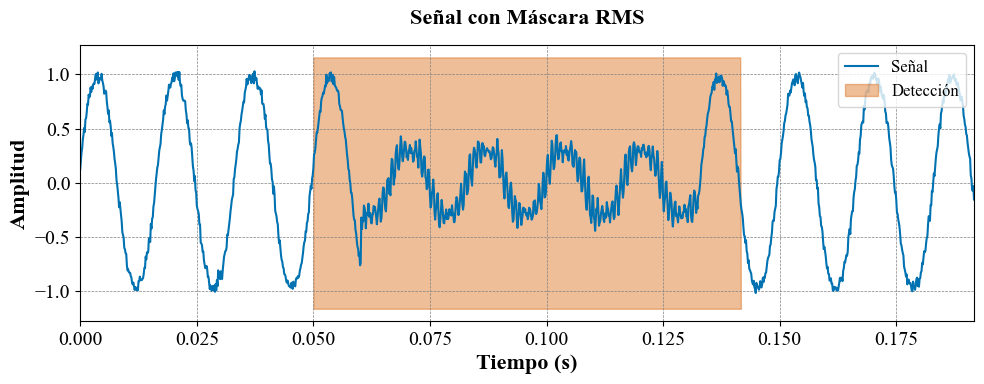

Gráfico guardado como: algoritmo_rms.svg


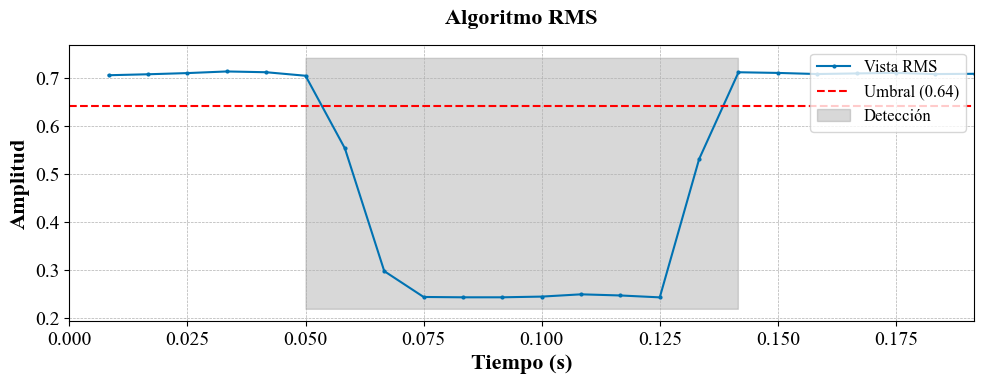

Gráfico guardado como: señal_con_máscara_hilbert.svg


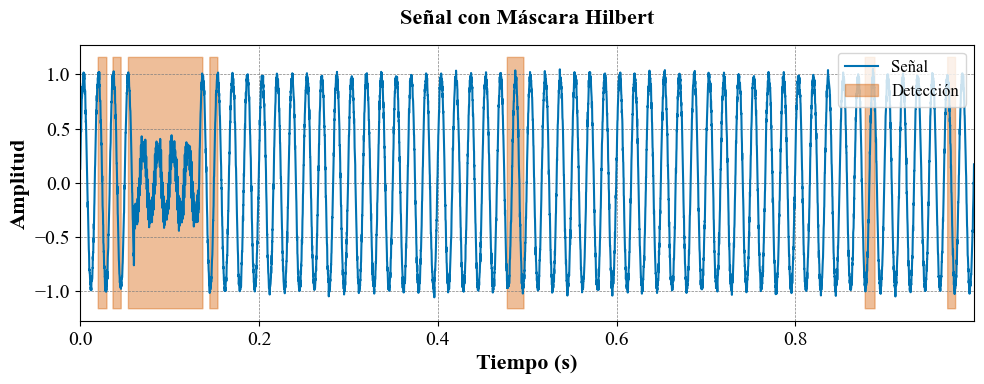

Gráfico guardado como: algoritmo_hilbert.svg


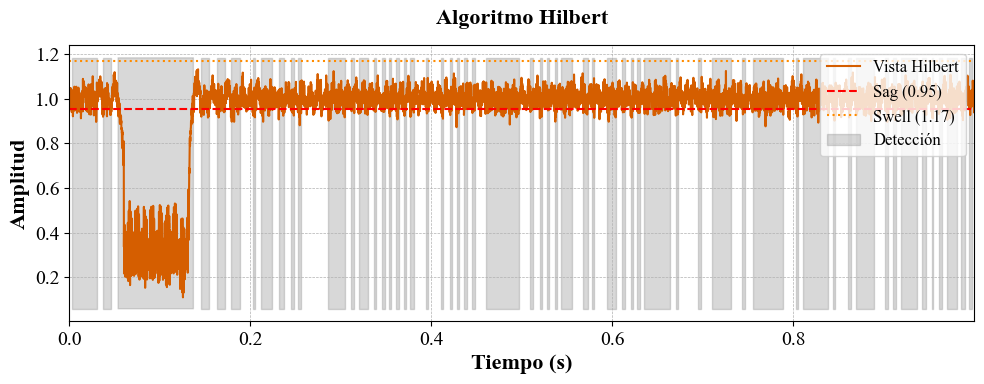

Gráfico guardado como: señal_con_máscara_wavelet.svg


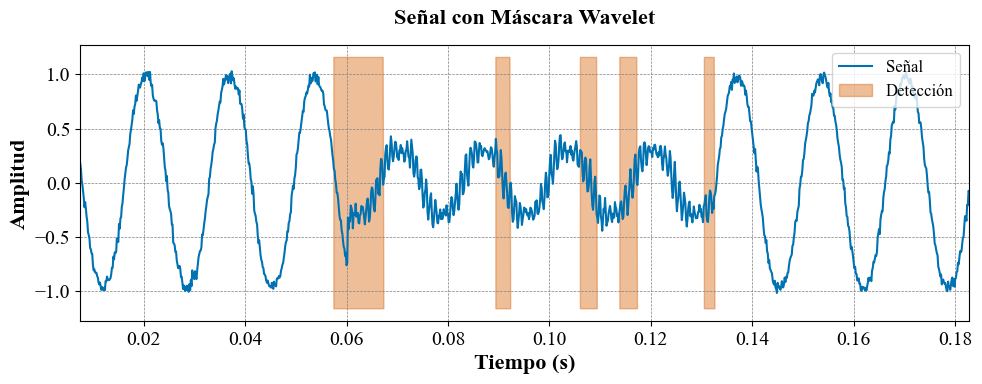

Gráfico guardado como: algoritmo_wavelet.svg


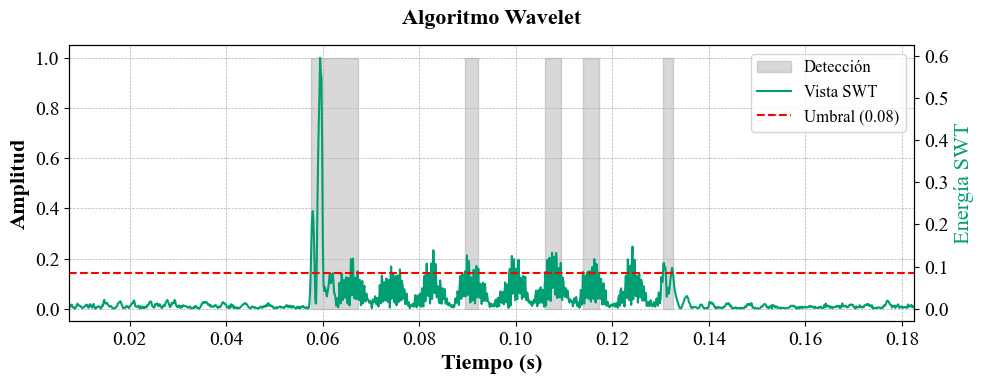

Gráfico guardado como: señal_con_máscara_fusión.svg


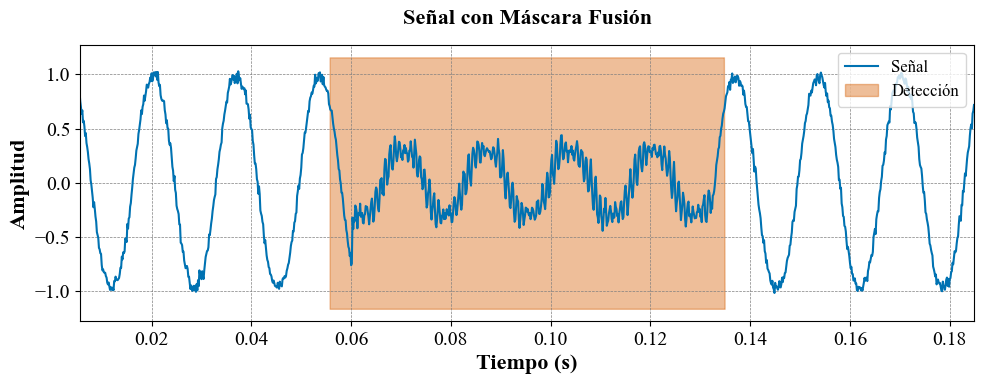

In [21]:
import pandas as pd

data0 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Normal\Clase_0_normal.csv'
data1 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag\Clase_1_sag.csv'
data2 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag_Armonic\Clase_2_Armonico.csv'
data3 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag_Multiple\Clase_3_sagmultiple.csv'
data4 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag_Notch\Clase_4_sagnotch.csv'
data5 = r'Sag_Transitorios\Clase_5_Transitorios.csv'

data2 =pd.read_csv(data2)

senal = data2['Sag_3100'].to_numpy()


datos_rms = generar_diagnostico_rms(senal,7200)
datos_hilbert = generar_diagnostico_hilbert(senal,7200)
datos_wavelet = generar_diagnostico_swt(senal,7200)

mascara_rms = detectar_eventos_rms(senal,7200)
mascara_hilbert = detectar_eventos_hilbert(senal,7200)
mascara_wavelet = detectar_eventos_swt(senal,7200)
mascara_fusion = detectar_eventos_con_fusion(senal,7200)

print(mascara_rms)
print(mascara_hilbert)
print(mascara_wavelet)
print(mascara_fusion)


señal_mascara(senal,mascara_rms,"Señal con Máscara RMS",7200)
plot_diagnostico_algoritmo(senal,"RMS",datos_rms,"Algoritmo RMS",7200)
señal_mascara(senal,mascara_hilbert,"Señal con Máscara Hilbert",7200)
plot_diagnostico_algoritmo(senal,"Hilbert",datos_hilbert,"Algoritmo Hilbert",7200)
señal_mascara(senal,mascara_wavelet,"Señal con Máscara Wavelet",7200)
plot_diagnostico_algoritmo(senal,"swt",datos_wavelet,"Algoritmo Wavelet",7200)
señal_mascara(senal,mascara_fusion,"Señal con Máscara Fusión",7200)